In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
from helpers.plot_seaborn import plot_seaborn

### Module 3.1: The "Why" of Plotting (A Plot is an Argument)

Most people think of a plot as a "picture of data". This is incorrect.

A plot is a **visual argument**. It is a form of communication, a claim you are making about the data. Your goal is not to "make a bar chart"; your goal is to "show a clear comparison between the revenues of three different groups." The bar chart is merely the tool you use to make that argument.

The "Statistician-Pythonista" understands this. The statistician asks, "What is the most honest and powerful argument I can make?" The pythonista asks, "What is the cleanest code to build the tool that makes that argument?"

### Module 3.2: The Grammar of Graphics

Just as English has a grammar (nouns, verbs, adjectives), so do plots. This theory, most famously articulated by Leland Wilkinson and Hadley Wickham, states that any plot is composed of distinct layers.

1.  **The Data:** The raw material. This is your DataFrame.
2.  **The Aesthetics (Mappings):** This is the link between your data and a visual property. You are *mapping* variables.
    * `x-axis_position` $\leftarrow$ `total_bill`
    * `y-axis_position` $\leftarrow$ `tip`
    * `color` $\leftarrow$ `smoker`
    * `size` $\leftarrow$ `party_size`
3.  **The Geometries (Geoms):** This is the *shape* you use to represent the data.
    * `geom_point()` (a scatter plot)
    * `geom_bar()` (a bar chart)
    * `geom_line()` (a line chart)

When you write `seaborn.scatterplot(x='total_bill', y='tip', hue='smoker')`, you are *not* just "making a scatter plot". You are explicitly declaring:
* **Data:** The (implicit) DataFrame.
* **Aesthetics:** Map `total_bill` to the x-axis, `tip` to the y-axis, and `smoker` to color.
* **Geometry:** Use points.

Why does this matter? Because you can change the geometry without changing the aesthetics. You could (though it might not make sense) apply a `geom_line()` to the same aesthetics, and the logic would hold. This "grammar" separates the *data* from its *visual representation*.

### Module 3.3: Graphical Integrity (How Not to Lie)

This is the ethical core of our module. Edward Tufte, a pioneer in this field, wrote extensively about "graphical integrity." The core principle is: **The representation of numbers on the graphic should be directly proportional to the numerical quantities represented.**

Anything else is a form of lying.

**The "Lie Factor"**
Tufte defined the "Lie Factor" as:
$\text{Lie Factor} = \frac{\text{Size of effect shown in graphic}}{\text{Size of effect in data}}$

If your data grew 10% (effect in data = 0.10), but you manipulated the chart so the bar *looks* 50% bigger (effect in graphic = 0.50), your Lie Factor is 5. A Lie Factor of 1 is honest.

The most common ways to lie (which you must avoid):

1.  **The Truncated Y-Axis (The Worst Offense):**
    This is the most common sin in business and media graphics.
    * **The Data:** Group A = 100, Group B = 110. This is a 10% difference.
    * **The Lie:** You start the Y-axis at 95 instead of 0. Now, the bar for Group B (height 15) is *three times taller* than the bar for Group A (height 5).
    * **The Result:** You have visually presented a 200% difference to show a 10% change. This is a lie.
    * **The Rule:** For bar charts, the Y-axis *must* start at 0. Line charts (showing change over time) are an exception, as their primary purpose is to show *slope*.
    

2.  **Using 3D Effects:**
    Never use 3D pie charts, 3D bars, or anything with perspective. The perspective distorts the relative sizes. The "closer" slice of a 3D pie chart looks far larger than an equal-sized slice in the "back". It adds no information and actively misleads.

3.  **Using Area/Volume for 1D Data:**
    If your revenue doubles, you might be tempted to make the *width* and *height* of your icon (e.g., a money bag) twice as big. The result is that the *area* is four times larger. The human eye perceives area, not just height. You have quadratically exaggerated your claim.

### Module 3.4: Choosing the Right Tool (The Statistician's Heuristics)

The final piece of the theory is matching the *question* to the *chart*. When you start an analysis, you have a question. The question dictates the plot.

Here are the four primary questions and their corresponding geometries:

* **1. "What does this variable look like?" (Showing a Distribution)**
    * **Goal:** To understand the *shape* of a single variable: its center, its spread, its skew, and its outliers.
    * **Tools (Geometries):**
        * **`histplot` (Histogram):** The workhorse. Shows frequency counts in discrete bins. Best for understanding the basic shape.
        * **`kdeplot` (Kernel Density Estimate):** A smoothed version of the histogram. Good for seeing the "shape" without the "noise" of bin sizes, but can be misleading (it might imply data exists where it does not, e.g., negative prices).
        * **`boxplot` (Box Plot):** The statistician's summary. Shows the median (50th percentile), the interquartile range (IQR, 25th-75th), and defines outliers (typically as points > 1.5 * IQR from the box). Excellent for comparing distributions across many groups.
        * **`violinplot`:** Combines a `boxplot` (in the middle) with a `kdeplot` (on the sides), showing both the summary statistics *and* the shape of the density.
    

* **2. "How do these two (or more) variables relate?" (Showing a Relationship)**
    * **Goal:** To see how one variable changes as another changes. This is the realm of correlation.
    * **Tools (Geometries):**
        * **`scatterplot`:** The primary tool. Every dot is an observation. You look for patterns: linear, curved, clustered, or no pattern at all.
        * **`pairplot`:** A matrix of scatterplots. The single fastest way to get a "first look" at all pairwise relationships in your dataset.

* **3. "How do these groups compare?" (Showing a Comparison)**
    * **Goal:** To compare a *numeric* value across different *categorical* groups.
    * **Tools (Geometries):**
        * **`barplot`:** The standard. The height of the bar represents a value (e.g., a count, or a `mean` aggregation). Remember: must start at Y=0.
        * **`pointplot`:** A `pointplot` is often better than a `barplot`. It shows the same mean value (the dot) but also adds *confidence intervals* (the vertical lines). This immediately tells you if the difference between two groups is *statistically significant* (if the confidence intervals do not overlap, the difference is likely real).
        * **`boxplot` / `violinplot`:** These are also comparison tools. `boxplot(x='day', y='tip')` is a far more robust comparison than `barplot(x='day', y='tip')`, as the bar plot only shows the *mean*, while the box plot shows the *entire distribution*.

* **4. "What is this data made of?" (Showing Composition)**
    * **Goal:** To show how a whole entity breaks down into parts.
    * **Tools (Geometries):**
        * **Stacked Bar Chart:** Good for showing how a total (the full bar) is divided into parts (the colored segments) across different groups.
        * **Pie Chart / Donut Chart:** Use *sparingly*. The human eye is terrible at comparing angles. It is only acceptable if you have 2-3 categories and want to show a simple "part-of-a-whole" (e.g., 75% Yes, 25% No). A bar chart is almost always better and more honest.



### Part 1: The "Whiteboarding" Exercise (Design)

For each scenario below, I am providing a small, synthetic dataset. Your task is to:

1.  **Experiment:** Run the starter code. Feel free to try multiple plot types (`barplot`, `boxplot`, `scatterplot`, etc.) to see what works and what does not.
2.  **Justify:** Write a short paragraph (2-4 sentences) justifying your *final* choice. Use the principles from Moment 1 (e.g., "A bar chart is poor here because... A boxplot is superior because it shows...").
3.  **Implement:** Provide the clean `seaborn` (or `matplotlib`) code for your chosen plot.

#### Scenario 1: The Unreadable Bar Chart

  * **Goal:** You are a data analyst at a large e-commerce company. A manager wants to see the "average shipping time" for the top 20 product categories.

  * **Minimal Starter Dataset:** This data represents the average shipping time in days for 20 categories.

In [3]:
# Synthetic Data
np.random.seed(42)
categories = [
	"art",
	"automotive",
	"baby",
	"beauty",
	"books",
	"clothing",
	"computers",
	"electronics",
	"garden",
	"grocery",
	"health",
	"home",
	"industrial",
	"jewelry",
	"music",
	"outdoors",
	"pets",
	"sports",
	"tools",
	"toys",
]

data_scenario_1 = pd.DataFrame({
	"category": categories,
	"avg_shipping_days": np.random.uniform(2.5, 9.0, size=len(categories)),
})

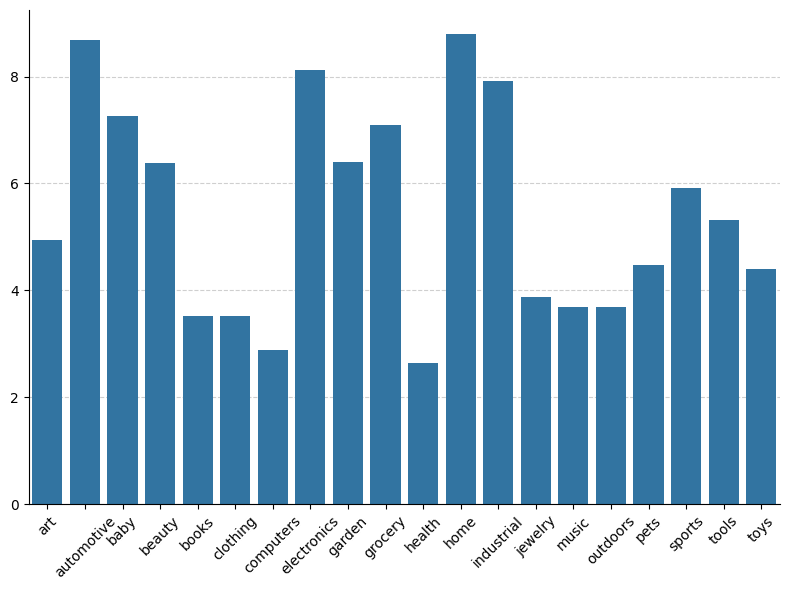

In [4]:
plot_seaborn(
	df=data_scenario_1,
	x="category",
	y="avg_shipping_days",
	plot_type="barplot",
	rotation=45,
	figsize=(8, 6),
)

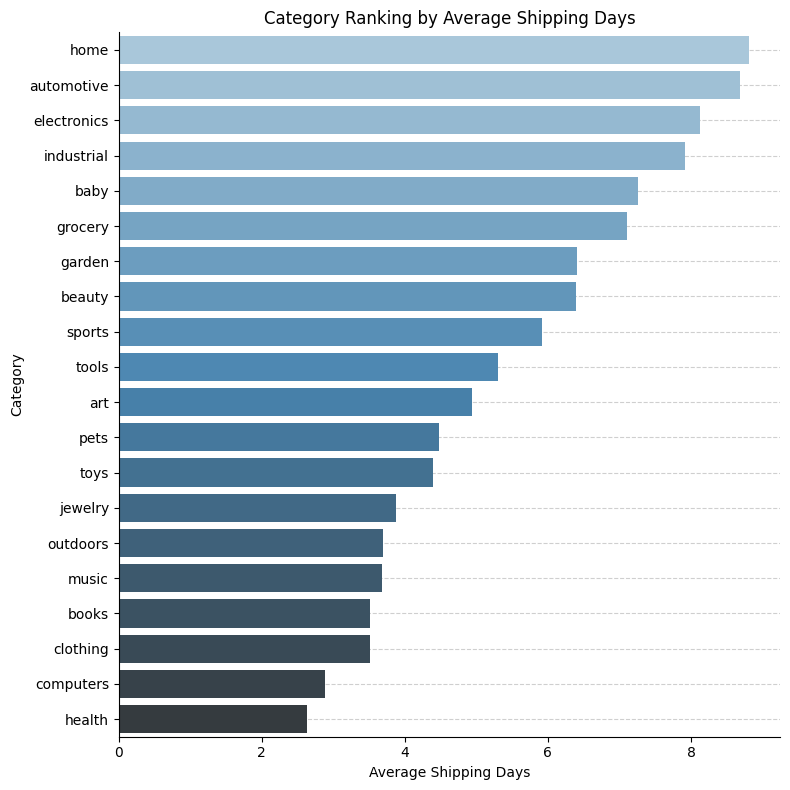

In [5]:
# Sort the data in descending order
sorted_values = data_scenario_1.sort_values(
	by="avg_shipping_days", ascending=False
).reset_index(drop=True)
sorted_values["rank"] = sorted_values.index + 1  # Add rank column for labeling

plot_seaborn(
	df=sorted_values,
	x="avg_shipping_days",
	y="category",
	plot_type="barplot",
	hue="category",
	palette="Blues_d",
	figsize=(8, 8),
	despine=True,
	xlabel="Average Shipping Days",
	ylabel="Category",
	title="Category Ranking by Average Shipping Days",
)

  * **The Task:** The standard bar chart is a mess (too many categories, unreadable x-axis labels, no clear pattern). Design and implement a *better* visualization that clearly shows the ranking and distribution of shipping times.

#### Scenario 2: The "Blob" of Data (Skewed Variables)

  * **Goal:** You are analyzing a housing dataset. You want to understand the relationship between "median income" (in tens of thousands) and "median house value".

  * **Minimal Starter Dataset:** This data is right-skewed, just like real financial data. Most people have low-to-medium income, but a few have very high income.

In [6]:
# Synthetic Data (log-normally distributed)
np.random.seed(42)
N_SAMPLES = 500
income = np.random.lognormal(mean=3.0, sigma=0.8, size=N_SAMPLES)
# House value is a function of income + some noise
house_value = (income * 50_000) + np.random.normal(0, 25_000, size=N_SAMPLES)
# Clamp values to be realistic
income = np.clip(income, 1, 50)
house_value = np.clip(house_value, 20_000, 500_000)

# Let's say population is somewhat correlated with income
population = (income * 1000) + np.random.randint(-500, 500, size=N_SAMPLES)
population = np.clip(population, 500, 50000)  # Ensure it's positive


data_scenario_2 = pd.DataFrame({
	"median_income_10k": income,
	"median_house_value": house_value,
	"population": population,
})

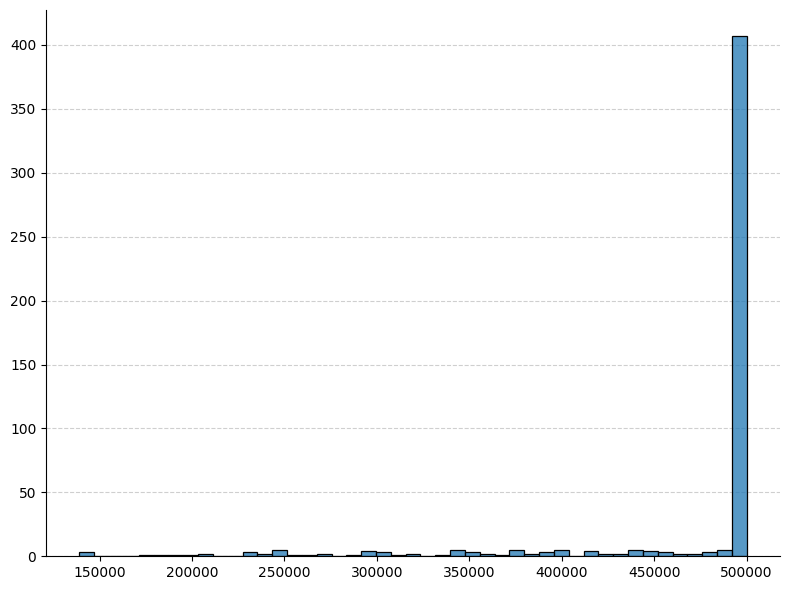

In [7]:
plot_seaborn(
	df=data_scenario_2,
	x="median_house_value",
	plot_type="histplot",
	figsize=(8, 6),
	despine=True,
)

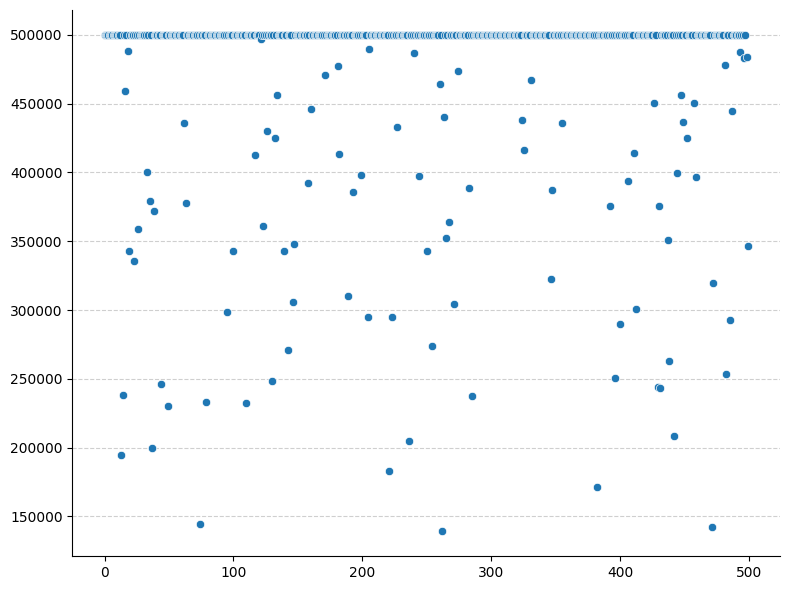

In [8]:
plot_seaborn(
	df=data_scenario_2["median_house_value"],
	plot_type="scatterplot",
	figsize=(8, 6),
	despine=True,
)

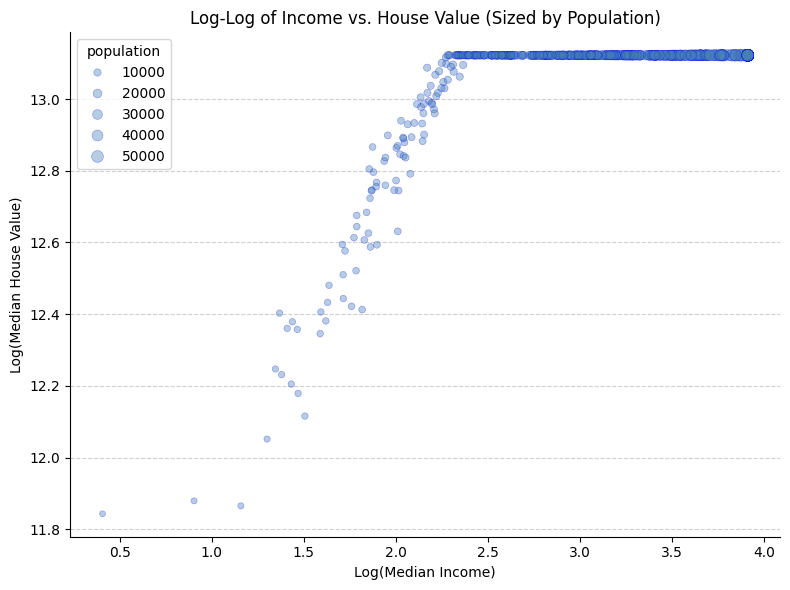

In [9]:
# Apply the log transforms
data_scenario_2["log_income"] = np.log(data_scenario_2["median_income_10k"])
data_scenario_2["log_value"] = np.log(data_scenario_2["median_house_value"])

plot_seaborn(
	df=data_scenario_2,
	x="log_income",
	y="log_value",
	plot_type="scatterplot",
	title="Log-Log of Income vs. House Value (Sized by Population)",
	xlabel="Log(Median Income)",
	ylabel="Log(Median House Value)",
	figsize=(8, 6),
	color="steelblue",
	edgecolor="blue",
	size="population",
	alpha=0.4,
)


  * **The Task:** The standard scatter plot is "blobbed" into the bottom-left corner, hiding the true relationship. Design and implement a visualization that *reveals* the underlying pattern. (Hint: How do statisticians handle skewed distributions?).

#### Scenario 3: Comparing Many Distributions

  * **Goal:** A marketing team wants to compare the `total_bill` for customers across all seven days of the week, broken down by whether they were a smoker or non-smoker. They want to see the *entire distribution* for each of these 14 groups, not just the mean.

  * **Minimal Starter Dataset:** We can use a real dataset for this one.

In [10]:
# Real Data
data_scenario_3 = sns.load_dataset("tips")
data_scenario_3.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


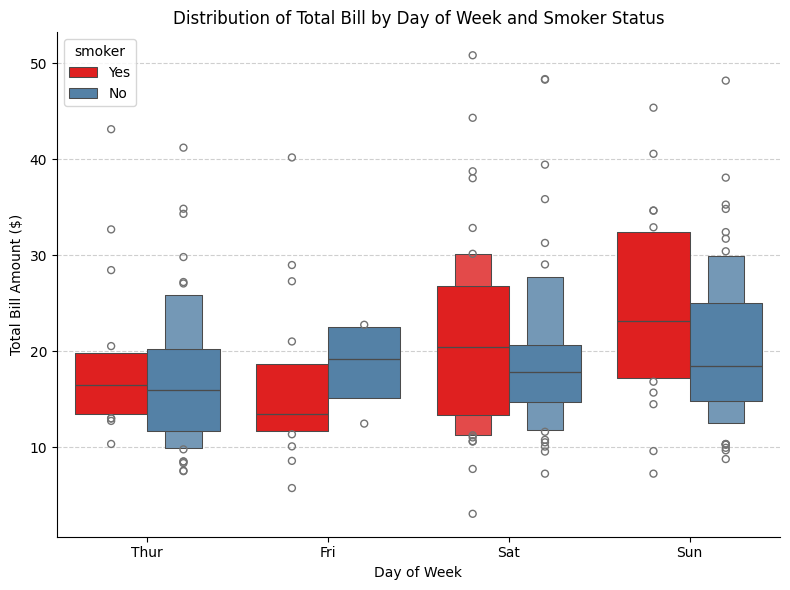

In [11]:
plot_seaborn(
	df=data_scenario_3,
	x="day",
	y="total_bill",
	plot_type="boxenplot",
	hue="smoker",
	palette={"Yes": "red", "No": "steelblue"},
	title="Distribution of Total Bill by Day of Week and Smoker Status",
	xlabel="Day of Week",
	ylabel="Total Bill Amount ($)",
	grid=True,
	figsize=(8, 6),
	despine=True,
)

  * **The Task:** Design and implement a *single* chart that allows for a robust comparison of all 14 distributions (7 days x 2 smoker statuses). A simple bar chart is not allowed, as it only shows the mean.


### Part 2: The "Critique" Exercise (The Rogues' Gallery)

For each scenario below, I will describe a "bad" chart and provide the data that made it. Your task is to:

1.  **Diagnose:** Identify the primary flaw (e.g., "Truncated Y-axis," "3D distortion").
2.  **Explain:** In 1-2 sentences, explain *why* it is misleading, using the principles of graphical integrity (e.g., "It violates the principle of proportionality...").
3.  **Implement:** Write the code for the *honest* and *effective* chart that answers the original question.

#### Bad Chart 1: The "Exaggerated Difference"

  * **The Chart:** A manager presents a `barplot` to compare the "Customer Satisfaction Score" (CSAT) for two marketing campaigns. Campaign A has a 91.4% score, and Campaign B has a 92.1% score. The chart shows the bar for Campaign B as being almost *twice as tall* as the bar for Campaign A.
  * **The Data:**

In [12]:
data_critique_1 = pd.DataFrame({
	"Campaign": ["Campaign A", "Campaign B"],
	"CSAT Score (%)": [91.4, 92.1],
})

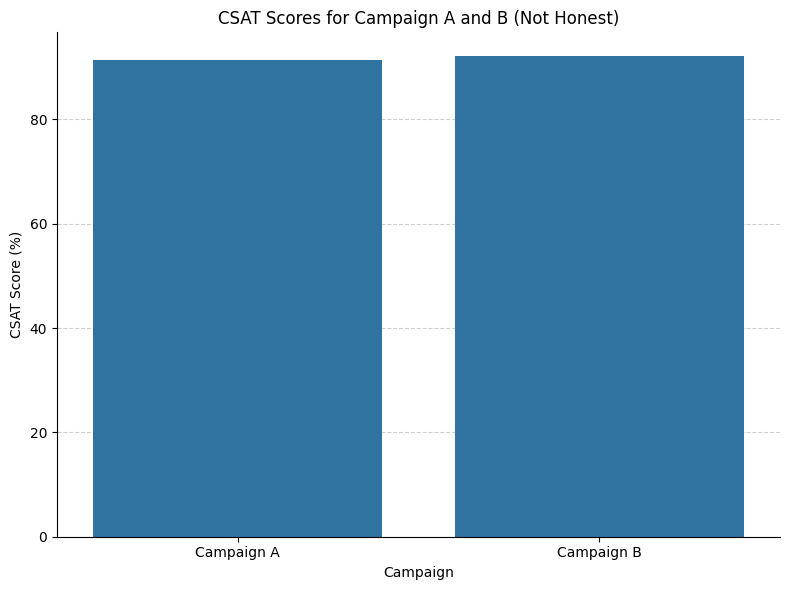

In [ ]:
# The bad barplot

plot_seaborn(
	df=data_critique_1,
	x="Campaign",
	y="CSAT Score (%)",
	plot_type="barplot",
	title="CSAT Scores for Campaign A and B (Not Honest)",
	xlabel="Campaign",
	ylabel="CSAT Score (%)",
	figsize=(8, 6),
	grid=True,
)

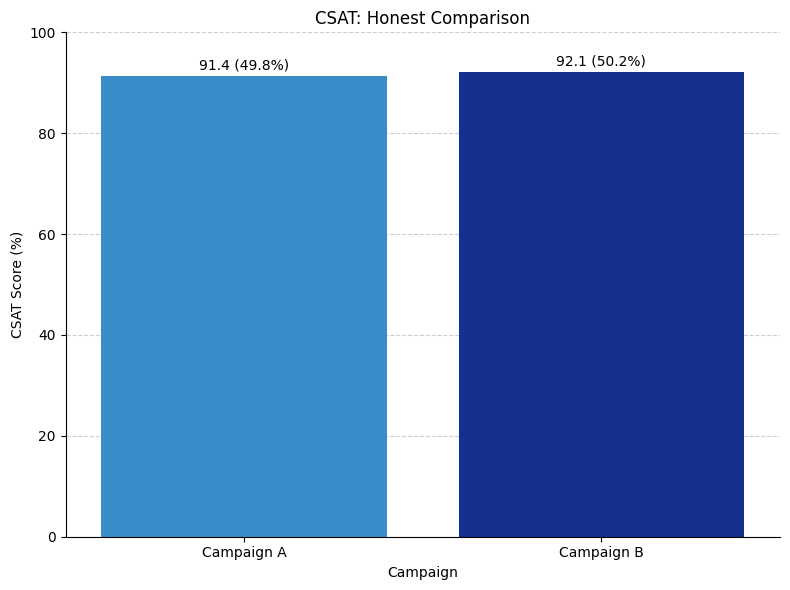

In [26]:
# The improved (honest) barplot
plot_seaborn(
	df=data_critique_1,
	x="Campaign",
	y="CSAT Score (%)",
	plot_type="barplot",
	title="CSAT: Honest Comparison",
	xlabel="Campaign",
	ylabel="CSAT Score (%)",
	hue="Campaign",
	palette=["#2190e0", "#0026a4ff"],
	figsize=(8, 6),
	grid=True,
	despine=True,
	ylim=(0, 100),
	annotate=True,
	annotation_font_kwargs={"size": 10, "weight": "normal"},
)

  * **Your Task:** Diagnose the flaw, explain why it's a lie (use Tufte's "Lie Factor" concept), and create the *honest* chart.

#### Bad Chart 2: The "Perspective Lie"

  * **The Chart:** An intern creates a 3D Pie Chart to show the breakdown of sales by product category. The slices are: `Electronics` (40%), `Home Goods` (30%), `Clothing` (15%), and `Grocery` (15%). The chart is tilted, and the "Clothing" slice (15%) is in the foreground, making it look visually *larger* than the "Home Goods" slice (30%) in the background.
  * **The Data:**

In [19]:
data_critique_2 = pd.DataFrame({
	"Category": ["Electronics", "Home Goods", "Clothing", "Grocery"],
	"Sales": [40, 30, 15, 15],
})

  * **Your Task:** Diagnose the flaw, explain why 3D pie charts are statistically unethical, and create a *better* chart (e.g., a bar chart or a clean 2D pie chart) that accurately represents the composition.

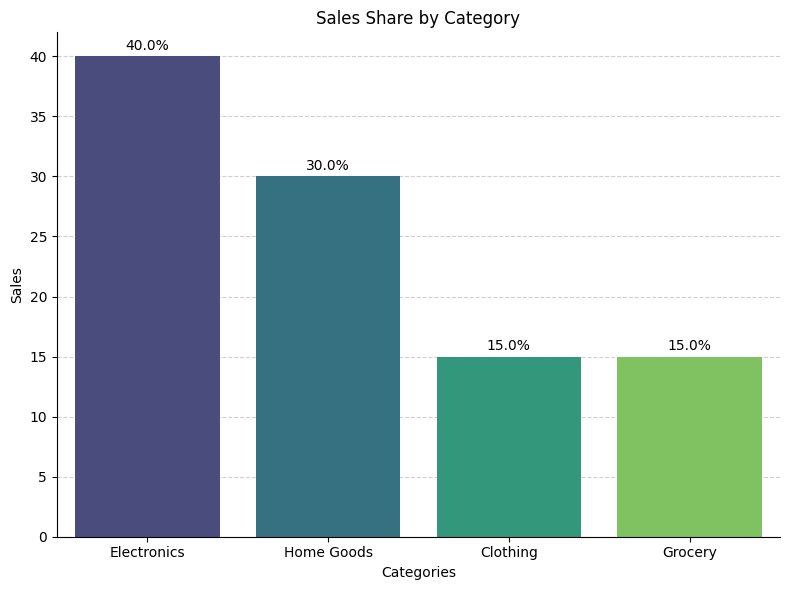

In [30]:
# Sort descending for immediate comparison
c2_sorted = data_critique_2.sort_values("Sales", ascending=False)

plot_seaborn(
	df=c2_sorted,
	plot_type="barplot",
	x="Category",
	y="Sales",
	hue="Category",
	palette="viridis",
	title="Sales Share by Category",
	xlabel="Categories",
	ylabel="Sales",
	figsize=(8, 6),
	grid=True,
	annotate=True,
	annotation_format="percent",
	annotation_font_kwargs={"size": 10, "weight": "normal"},
)


#### Bad Chart 3: The "Spurious Correlation"

  * **The Chart:** A blogger creates a line chart plotting two variables on *two different Y-axes*.
      * **Left Y-Axis (Blue Line):** "Global Average Temperature" (from 14.0 to 14.5 °C)
      * **Right Y-Axis (Red Line):** "Number of Software Developers" (from 15M to 25M)
      * The lines are scaled to perfectly overlap, making it look like the number of developers is *causing* global warming.
  * **The Data:**

In [32]:
data_critique_3 = pd.DataFrame({
	"Year": [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019],
	"Global_Temp_C": [
		14.01,
		14.05,
		14.10,
		14.12,
		14.18,
		14.25,
		14.31,
		14.35,
		14.40,
		14.45,
	],
	"Developers_M": [15.1, 15.5, 16.2, 17.0, 18.1, 19.0, 20.1, 21.5, 23.0, 24.5],
})

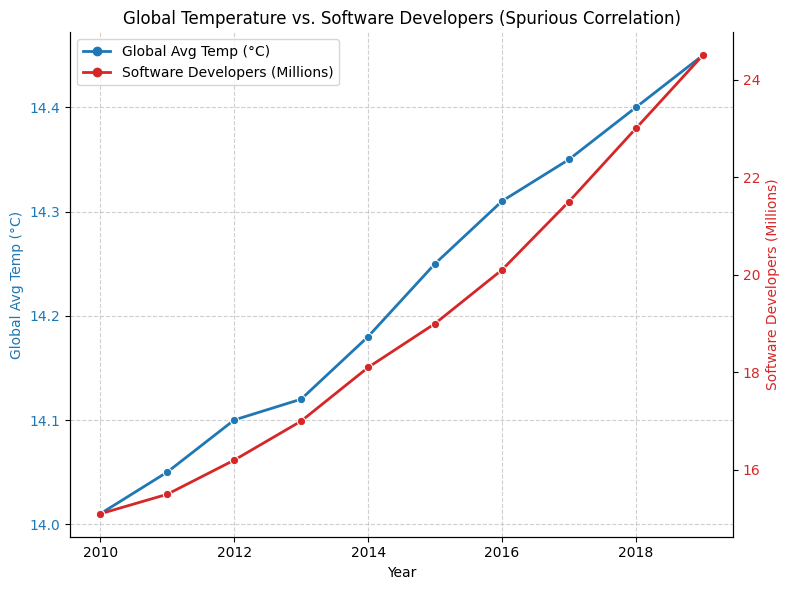

In [47]:
from matplotlib.lines import Line2D

fig, ax1 = plt.subplots(figsize=(8, 6))

# Left axis
sns.lineplot(
	data=data_critique_3,
	x="Year",
	y="Global_Temp_C",
	color="tab:blue",
	marker="o",
	linewidth=2,
	ax=ax1,
	legend=False,
)
ax1.set_ylabel("Global Avg Temp (°C)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Right axis
ax2 = ax1.twinx()
sns.lineplot(
	data=data_critique_3,
	x="Year",
	y="Developers_M",
	color="tab:red",
	marker="o",
	linewidth=2,
	ax=ax2,
	legend=False,
)
ax2.set_ylabel("Software Developers (Millions)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_title("Global Temperature vs. Software Developers (Spurious Correlation)")
ax1.grid(True, linestyle="--", alpha=0.6)
sns.despine(fig=fig, right=False)

# Manual legend using proxy handles
handles = [
	Line2D(
		[0],
		[0],
		color="tab:blue",
		marker="o",
		linewidth=2,
		label="Global Avg Temp (°C)",
	),
	Line2D(
		[0],
		[0],
		color="tab:red",
		marker="o",
		linewidth=2,
		label="Software Developers (Millions)",
	),
]
ax1.legend(handles=handles, loc="upper left", frameon=True)

plt.tight_layout()
plt.show()


  * **Your Task:** Diagnose the flaw (it is called a "dual-axis" plot), explain why this is a classic statistical sin, and create an *honest* visualization (or two) to show the *real* relationship (or lack thereof). (Hint: What is the *correct* way to show a relationship between two numeric variables?).

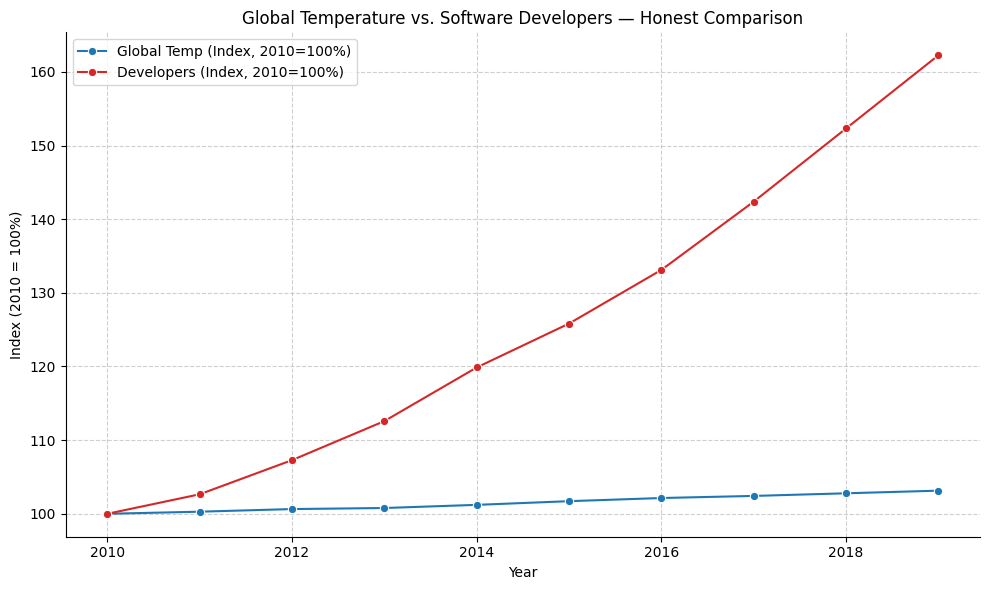

In [ ]:
data = data_critique_3.copy()

# Use .iat[0] to fetch the first element directly
data["Temp_Index"] = 100 * data["Global_Temp_C"] / data["Global_Temp_C"].iat[0]
data["Dev_Index"] = 100 * data["Developers_M"] / data["Developers_M"].iat[0]

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
	data=data,
	x="Year",
	y="Temp_Index",
	color="tab:blue",
	marker="o",
	label="Global Temp (Index, 2010=100%)",
	ax=ax,
)
sns.lineplot(
	data=data,
	x="Year",
	y="Dev_Index",
	color="tab:red",
	marker="o",
	label="Developers (Index, 2010=100%)",
	ax=ax,
)

ax.set_ylabel("Index (2010 = 100%)")
ax.set_title("Global Temperature vs. Software Developers — Honest Comparison")
ax.grid(True, linestyle="--", alpha=0.6)
sns.despine()
plt.legend()
plt.tight_layout()
plt.show()
